In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style("whitegrid")
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
plt.style.use('dark_background')


In [4]:
df = pd.read_csv('cleaned_road_data.csv')

In [5]:
df.head()

,Accident_Index,Accident Date,Month,Day_of_Week,Year,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,...,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,200901BS70001,1/1/2021,Jan,Thursday,2021,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,...,1,2,Metropolitan Police,Dry,One way street,30,15:11,Urban,Fine no high winds,Car
1,200901BS70002,1/5/2021,Jan,Monday,2021,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,...,11,2,Metropolitan Police,Wet or damp,Single carriageway,30,10:59,Urban,Fine no high winds,Taxi/Private hire car
2,200901BS70003,1/4/2021,Jan,Sunday,2021,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,...,1,2,Metropolitan Police,Dry,Single carriageway,30,14:19,Urban,Fine no high winds,Taxi/Private hire car
3,200901BS70004,1/5/2021,Jan,Monday,2021,Auto traffic signal,T or staggered junction,Serious,51.507804,Daylight,...,1,2,Metropolitan Police,Frost or ice,Single carriageway,30,8:10,Urban,Other,Motorcycle over 500cc
4,200901BS70005,1/6/2021,Jan,Tuesday,2021,Auto traffic signal,Crossroads,Serious,51.482076,Darkness - lights lit,...,1,2,Metropolitan Police,Dry,Single carriageway,30,17:25,Urban,Fine no high winds,Car


In [6]:
df.shape

(307972, 22)

In [7]:
df['Accident Date'] = pd.to_datetime(df['Accident Date'])


In [8]:
df['Year'] = df['Accident Date'].dt.year
df['Month'] = df['Accident Date'].dt.month
df['Day'] = df['Accident Date'].dt.day
df['Weekday'] = df['Accident Date'].dt.day_name()


In [9]:
df.shape

(307972, 24)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307972 entries, 0 to 307971
Data columns (total 24 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Accident_Index              307972 non-null  object        
 1   Accident Date               307972 non-null  datetime64[ns]
 2   Month                       307972 non-null  int32         
 3   Day_of_Week                 307972 non-null  object        
 4   Year                        307972 non-null  int32         
 5   Junction_Control            307972 non-null  object        
 6   Junction_Detail             307972 non-null  object        
 7   Accident_Severity           307972 non-null  object        
 8   Latitude                    307972 non-null  float64       
 9   Light_Conditions            307972 non-null  object        
 10  Local_Authority_(District)  307972 non-null  object        
 11  Longitude                   307972 non-

# EDA

In [11]:
df['Accident Date'].dtype

dtype('<M8[ns]')

In [12]:
# Numeric columns (int or float)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Categorical columns (object or category)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Boolean columns (True/False)
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()

# Datetime columns
datetime_cols = df.select_dtypes(include=['datetime64']).columns.tolist()

In [13]:
numeric_cols

['Latitude',
 'Longitude',
 'Number_of_Casualties',
 'Number_of_Vehicles',
 'Speed_limit']

In [14]:
categorical_cols

['Accident_Index',
 'Day_of_Week',
 'Junction_Control',
 'Junction_Detail',
 'Accident_Severity',
 'Light_Conditions',
 'Local_Authority_(District)',
 'Police_Force',
 'Road_Surface_Conditions',
 'Road_Type',
 'Time',
 'Urban_or_Rural_Area',
 'Weather_Conditions',
 'Vehicle_Type',
 'Weekday']

In [15]:
bool_cols

[]

In [16]:
datetime_cols

['Accident Date']

## 1. Categorical Data


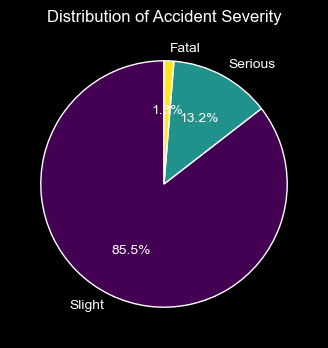

In [31]:
plt.figure(figsize=(6,4))
df['Accident_Severity'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, colormap='viridis')
plt.title('Distribution of Accident Severity')
plt.ylabel('')
plt.show()


#### Insight:
- Most accidents fall under the Slight severity category, followed by Serious, and only a very small number are Fatal.
### Conclusion: 
Most accidents are minor in nature.

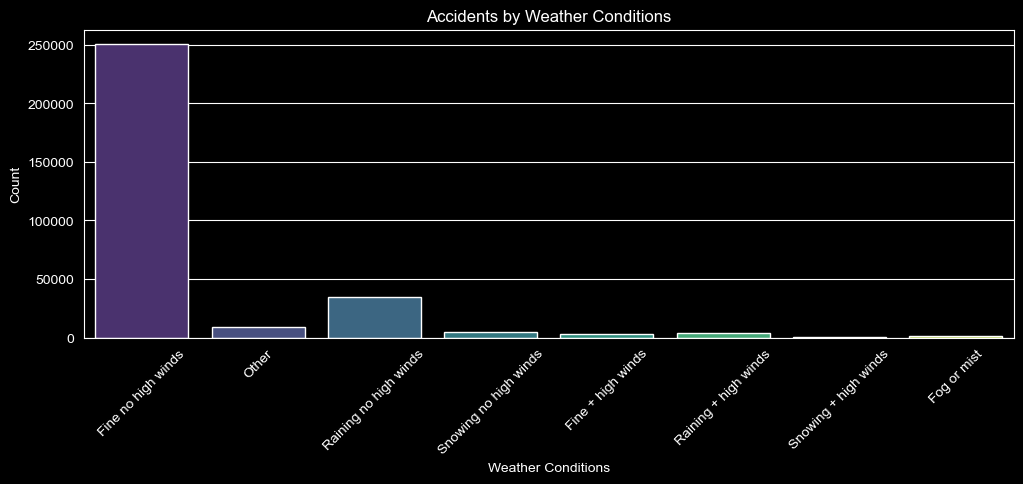

Weather_Conditions
Fine no high winds       250552
Raining no high winds     34877
Other                      8802
Snowing no high winds      4839
Raining + high winds       3526
Fine + high winds          3148
Fog or mist                1690
Snowing + high winds        538
Name: count, dtype: int64

In [18]:
plt.figure(figsize=(12,4))
sns.countplot(x='Weather_Conditions', data=df, palette='viridis')
plt.title('Accidents by Weather Conditions')
plt.xlabel('Weather Conditions')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

df['Weather_Conditions'].value_counts()


### Insight for Weather Conditions :

- Majority of accidents happened during “Fine no high winds” weather (≈ 2.5 lakh cases).
- Second highest category is “Raining no high winds”, but the count is much smaller compared to clear weather.
- Very few accidents happened in extreme conditions like Snowing or Fog/Mist.

### Conclusion
Weather is not the main reason for accidents. Most crashes happened in normal clear weather, which means road accidents are mainly caused by driver behavior, traffic density, and road conditions, not because of bad weather.

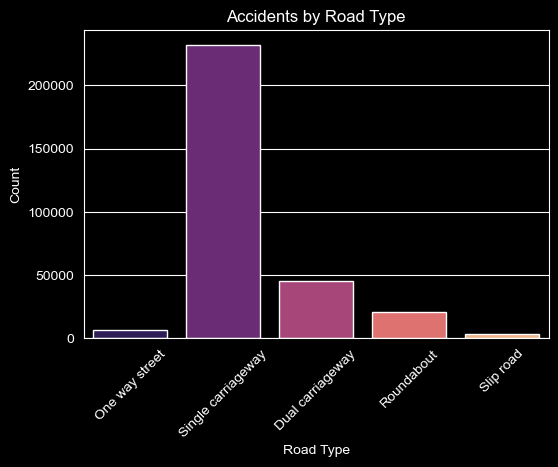

Road_Type
Single carriageway    232145
Dual carriageway       45467
Roundabout             20929
One way street          6197
Slip road               3234
Name: count, dtype: int64

In [35]:
plt.figure(figsize=(6,4))
sns.countplot(x='Road_Type', data=df, palette='magma')
plt.title('Accidents by Road Type')
plt.xlabel('Road Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

df['Road_Type'].value_counts()


### Insight for Road Type
- Most accidents occurred on Single carriageway roads.
- Accidents on Dual carriageway are much less compared to single lane roads.
- Very few accidents happened on Roundabouts and Slip roads.
  
### Conclusion
Single carriageway roads have the highest accident risk. These roads usually have traffic moving in both directions without any physical divider, so the chances of collision are higher compared to divided dual roads.

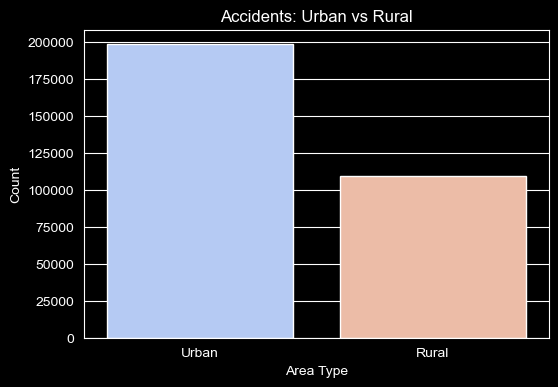

Urban_or_Rural_Area
Urban    198532
Rural    109440
Name: count, dtype: int64

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x='Urban_or_Rural_Area', data=df, palette='coolwarm')
plt.title('Accidents: Urban vs Rural')
plt.xlabel('Area Type')
plt.ylabel('Count')
plt.show()

df['Urban_or_Rural_Area'].value_counts()


### Insight for Urban or Rural Area
- Most of the accidents occurred in Urban areas.
- The number of accidents in Rural areas is comparatively much lower.

### Conclusion
Urban regions have heavier traffic, higher vehicle density, more junctions, and more pedestrian movement, which increases the chance of accidents. This shows that accident risk is mainly concentrated in busy city regions rather than rural roads.

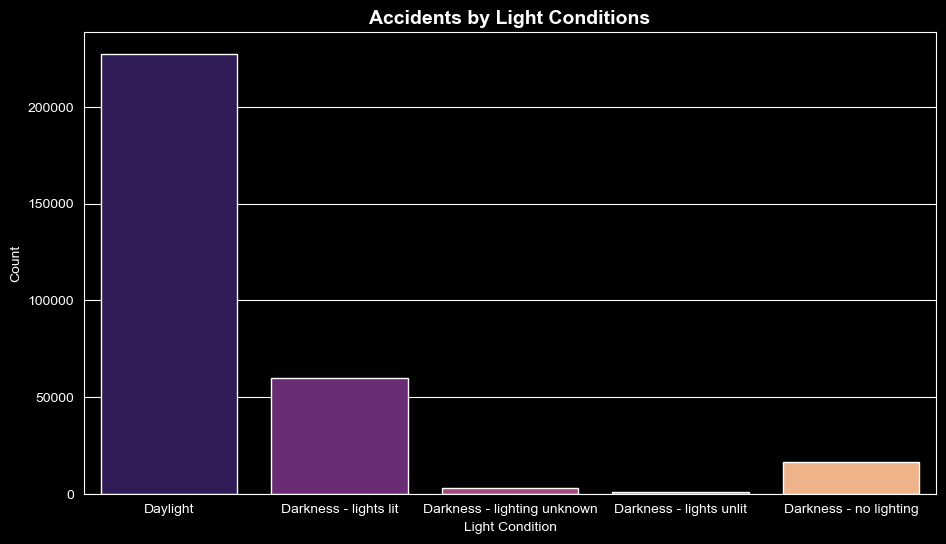

In [21]:
plt.figure(figsize=(11,6))
sns.countplot(data=df, x='Light_Conditions', palette='magma')
plt.title('Accidents by Light Conditions', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.xlabel('Light Condition')
plt.show()


### Insight for Light Conditions:
Most accidents happen during daylight hours.

### Conclusion :
Even in daytime, accidents are high, so good light does not guarantee safe driving.

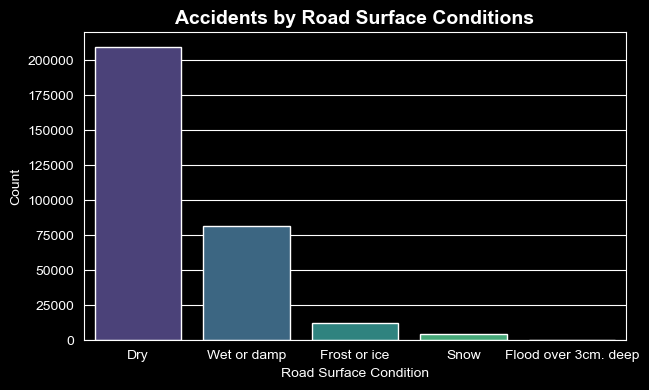

In [36]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='Road_Surface_Conditions', palette='viridis')
plt.title('Accidents by Road Surface Conditions', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.xlabel('Road Surface Condition')
plt.show()


### Insight for Road Surface Conditions:
Most accidents occur on dry roads.

### Conclusion :
Accidents are not always because of slippery or wet roads — even normal dry roads have high accident cases, mainly due to driver behavior and traffic.

In [23]:
df.to_csv('final_cleaned.csv', index=False)

## 2. Numerical data

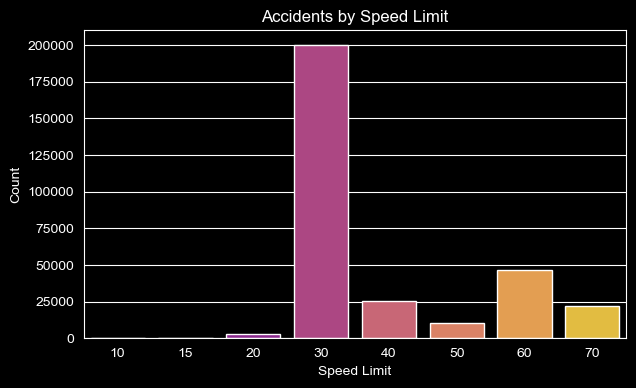

Speed_limit
30    200040
60     46826
40     25650
70     22362
50     10190
20      2899
10         3
15         2
Name: count, dtype: int64

In [24]:
plt.figure(figsize=(7,4))
sns.countplot(x='Speed_limit', data=df, palette='plasma')
plt.title('Accidents by Speed Limit')
plt.xlabel('Speed Limit')
plt.ylabel('Count')
plt.show()

df['Speed_limit'].value_counts()


### Insight for Speed Limit
- Most accidents occur on roads with a 30 mph speed limit.
- The number of accidents reduces as the speed limit increases (40 mph, 50 mph, 60 mph).
- Very few accidents occur on very high-speed or very low-speed roads.
### Conclusion
Majority of accidents happen on 30 mph roads because these roads are mainly inside urban city areas where vehicle volume is very high. Even though speed is low, the traffic density is high → more vehicles, more turns, more signals, more pedestrians → so chances of collision increase.

This shows that accident frequency is influenced more by traffic load than by speed limit.

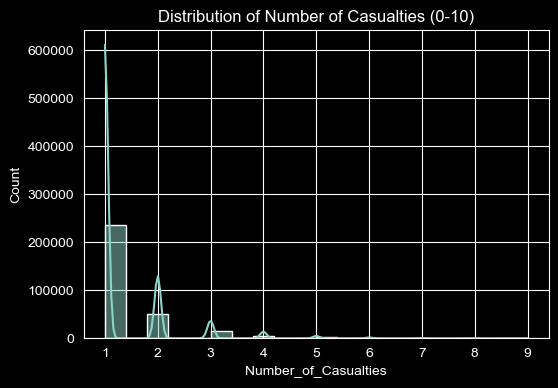

In [25]:
plt.figure(figsize=(6,4))
sns.histplot(data=df[df['Number_of_Casualties'] < 10], x='Number_of_Casualties', kde=True)
plt.title('Distribution of Number of Casualties (0-10)')
plt.show()


### Insight
- Majority of accidents have very low casualties (mainly 1 or 2).
- Very high casualty accidents are very rare and exist as outliers.

### Conclusion
Most accidents do not cause heavy harm to many people. The casualty count is mostly low per accident, which indicates that most crashes are minor and not mass casualty events.

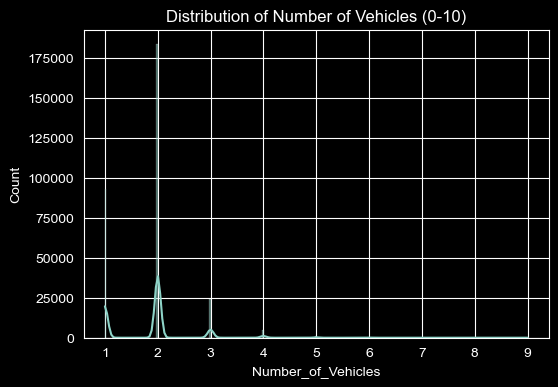

In [26]:
plt.figure(figsize=(6,4))
sns.histplot(data=df[df['Number_of_Vehicles'] < 10], x='Number_of_Vehicles', kde=True)
plt.title('Distribution of Number of Vehicles (0-10)')
plt.show()


### Insight
- Most accidents involve only 1 or 2 vehicles.
- Accidents involving many vehicles (like 4, 5, 6+) are uncommon.

### Conclusion
  Most accidents happen with only 1 or 2 vehicles. Big accidents with many vehicles are very rare.

In [27]:
df.columns

Index(['Accident_Index', 'Accident Date', 'Month', 'Day_of_Week', 'Year',
       'Junction_Control', 'Junction_Detail', 'Accident_Severity', 'Latitude',
       'Light_Conditions', 'Local_Authority_(District)', 'Longitude',
       'Number_of_Casualties', 'Number_of_Vehicles', 'Police_Force',
       'Road_Surface_Conditions', 'Road_Type', 'Speed_limit', 'Time',
       'Urban_or_Rural_Area', 'Weather_Conditions', 'Vehicle_Type', 'Day',
       'Weekday'],
      dtype='object')

In [28]:
df['Accident_Severity'].unique()

array(['Serious', 'Slight', 'Fatal'], dtype=object)

In [29]:
df['Time'].dtype

dtype('O')

In [30]:
df['Month'].dtype

dtype('int32')